In [ ]:
# 🚀 CrewOps — Multi-Agent DevOps Incident Analysis Suite

'''**End-to-End Workflow Notebook | Local Development Edition**

---

## Problem Statement
Modern DevOps teams face an overwhelming volume of operational logs during incidents. Manual triage is slow, error-prone, and disconnected from downstream actions like ticket creation and team notifications.

## Solution: CrewOps
An enterprise-grade **multi-agent DevOps incident intelligence platform** powered by:

| Layer | Technology | Purpose |
|-------|-----------|---------|
| **Orchestration** | LangGraph StateGraph | 7-agent conditional pipeline |
| **AI Models** | OpenRouter (multi-model) | Right-sized model per agent role |
| **RAG** | LanceDB + LlamaIndex | Retrieves historical runbooks & SOPs |
| **Observability** | LangSmith | Full trace of every agent decision |
| **Notifications** | n8n + Slack | Redundant alerting with fallback |
| **Ticketing** | JIRA Cloud | Auto-creates P1/P2 tickets |
| **Ops UI** | Streamlit | Production-grade incident dashboard |

## Notebook Flow
Run cells **in order** — each phase builds on the previous one.

| Phase | Cells | Purpose |
|-------|-------|---------|
| **1** | 3–5 | Install deps, env config, LLM init |
| **2** | 7–11 | Inspect state, agents, graph |
| **3** | 13–16 | RAG knowledge base — build & verify |
| **4** | 18–21 | Execute pipeline, display results |
| **5** | 23–24 | Run test suite |
| **6** | 26–27 | Launch Streamlit production dashboard |
| **7** | 29 | Smoke tests & wrap-up |'''


'**End-to-End Workflow Notebook | Local Development Edition**\n\n---\n\n## Problem Statement\nModern DevOps teams face an overwhelming volume of operational logs during incidents. Manual triage is slow, error-prone, and disconnected from downstream actions like ticket creation and team notifications.\n\n## Solution: CrewOps\nAn enterprise-grade **multi-agent DevOps incident intelligence platform** powered by:\n\n| Layer | Technology | Purpose |\n|-------|-----------|---------|\n| **Orchestration** | LangGraph StateGraph | 7-agent conditional pipeline |\n| **AI Models** | OpenRouter (multi-model) | Right-sized model per agent role |\n| **RAG** | LanceDB + LlamaIndex | Retrieves historical runbooks & SOPs |\n| **Observability** | LangSmith | Full trace of every agent decision |\n| **Notifications** | n8n + Slack | Redundant alerting with fallback |\n| **Ticketing** | JIRA Cloud | Auto-creates P1/P2 tickets |\n| **Ops UI** | Streamlit | Production-grade incident dashboard |\n\n## Notebook

In [ ]:
## 📦 Phase 1: Project Setup

'''Install dependencies from `pyproject.toml`, configure environment variables, and initialise the LLMs.'''


'Install dependencies from `pyproject.toml`, configure environment variables, and initialise the LLMs.'

In [ ]:
# ============================================================
# CELL 1: Install Dependencies from pyproject.toml
# Installs all extras: rag (LanceDB + HuggingFace embeddings)
#                      ui  (Streamlit)
#                      test (pytest)
# Uses the repo root dynamically — works on any machine.
# ============================================================
import subprocess, sys
from pathlib import Path

# Locate repo root dynamically (same logic as Cell 2)
def _find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists() or (candidate / ".git").exists():
            return candidate
    return Path.cwd()

_repo_root = _find_repo_root()
print(f"📦 Installing CrewOps package from: {_repo_root}")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-e", ".[rag,ui,test]"],
    cwd=str(_repo_root),
    check=True
)

# ── Verify all critical imports ───────────────────────────────
checks = [
    ("LangChain stack",         "import langchain_core, langgraph, langsmith, langchain_openrouter"),
    ("RAG — LanceDB + LlamaIndex", "import lancedb, llama_index"),
    ("RAG — HuggingFace embeddings", "from llama_index.embeddings.huggingface import HuggingFaceEmbedding"),
    ("RAG — sentence-transformers", "import sentence_transformers"),
    ("JIRA client",             "import jira"),
    ("Streamlit UI",            "import streamlit"),
    ("crewops package",         "from crewops.state import CrewOpsState; from crewops.graph import build_graph"),
]

all_ok = True
for label, stmt in checks:
    try:
        exec(stmt)
        print(f"✅ {label} — OK")
    except ImportError as e:
        print(f"❌ {label} — {e}")
        all_ok = False

print()
print("✅ All dependencies verified!" if all_ok else "⚠️  Some imports failed — check output above")
print("=" * 60)


📦 Installing CrewOps package from: /Users/sannithkumar/git/CrewOps


✅ LangChain stack — OK
✅ RAG — LanceDB + LlamaIndex — OK
✅ RAG — HuggingFace embeddings — OK
✅ RAG — sentence-transformers — OK
✅ JIRA client — OK
✅ Streamlit UI — OK
✅ crewops package — OK

✅ All dependencies verified!



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# ============================================================
# CELL 2: Configuration & Environment Setup
# Loads from .env at project root — works for any clone path.
# ============================================================
import os
from pathlib import Path
from dotenv import load_dotenv

# ── Locate repo root dynamically (no hardcoded paths) ────────
# Walks up from the current working directory until it finds
# pyproject.toml or .git — works regardless of where the repo
# is cloned on any team member's machine.
def _find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists() or (candidate / ".git").exists():
            return candidate
    return Path.cwd()

REPO_ROOT = _find_repo_root()
env_path  = REPO_ROOT / ".env"
loaded    = load_dotenv(env_path, override=True)   # override=True ensures .env beats any stale env vars
print(f"{'✅' if loaded else '⚠️ '} .env loaded from: {env_path}")
print(f"   Repo root detected: {REPO_ROOT}")

# ── LangSmith Observability ───────────────────────────────────
os.environ.setdefault("LANGCHAIN_TRACING_V2", "true")
os.environ.setdefault("LANGCHAIN_PROJECT",    "CrewOps-Hackathon")

langchain_key  = os.environ.get("LANGCHAIN_API_KEY", "")
openrouter_key = os.environ.get("OPENROUTER_API_KEY", "")

print(f"\n{'✅' if langchain_key  else '⚠️ '} LangSmith  — {'tracing enabled' if langchain_key  else 'LANGCHAIN_API_KEY missing'}")
print(f"{'✅' if openrouter_key else '❌'} OpenRouter — {'key loaded'      if openrouter_key else 'OPENROUTER_API_KEY required!'}")

# ── Integration flags — read from .env values ─────────────────
# Set JIRA_MOCK_MODE=false / NOTIFICATION_MOCK_MODE=false in .env for live mode.
JIRA_MOCK_MODE         = os.environ.get("JIRA_MOCK_MODE",         "true").strip().lower() not in ("false", "0", "no")
NOTIFICATION_MOCK_MODE = os.environ.get("NOTIFICATION_MOCK_MODE", "true").strip().lower() not in ("false", "0", "no")
N8N_WEBHOOK_URL        = os.environ.get("N8N_WEBHOOK_URL",        "")
SLACK_WEBHOOK_URL      = os.environ.get("SLACK_WEBHOOK_URL",      "")
JIRA_SERVER            = os.environ.get("JIRA_SERVER",            "https://your-domain.atlassian.net")
JIRA_EMAIL             = os.environ.get("JIRA_EMAIL",             "")
JIRA_API_TOKEN         = os.environ.get("JIRA_API_TOKEN",         "")
JIRA_PROJECT_KEY       = os.environ.get("JIRA_PROJECT_KEY",       "OPS")

print(f"\n🔧 Integration Modes:")
print(f"   JIRA          → {'MOCK 🟡' if JIRA_MOCK_MODE else 'LIVE 🟢  ' + JIRA_SERVER}")
print(f"   Notifications → {'MOCK 🟡' if NOTIFICATION_MOCK_MODE else 'LIVE 🟢  n8n/Slack'}")
if not JIRA_MOCK_MODE:
    print(f"   JIRA email    → {JIRA_EMAIL    or '❌ JIRA_EMAIL missing in .env'}")
    print(f"   JIRA token    → {'✅ set' if JIRA_API_TOKEN else '❌ JIRA_API_TOKEN missing in .env'}")
    print(f"   JIRA project  → {JIRA_PROJECT_KEY}")
if not NOTIFICATION_MOCK_MODE:
    print(f"   n8n URL       → {N8N_WEBHOOK_URL   or '⚠️  N8N_WEBHOOK_URL not set (Slack fallback)'}")
    print(f"   Slack URL     → {'✅ set' if SLACK_WEBHOOK_URL else '⚠️  SLACK_WEBHOOK_URL not set'}")

# ── Model Presets ─────────────────────────────────────────────
MODEL_PRESETS = {
    "fast":       "openai/gpt-4o-mini",
    "reasoning":  "openai/gpt-4o",
    "generation": "openai/gpt-4o-mini",
}
print(f"\n🤖 Model Presets:")
for role, model in MODEL_PRESETS.items():
    print(f"   {role:12} → {model}")
print("=" * 60)


✅ .env loaded from: /Users/sannithkumar/git/CrewOps/.env
   Repo root detected: /Users/sannithkumar/git/CrewOps

✅ LangSmith  — tracing enabled
✅ OpenRouter — key loaded

🔧 Integration Modes:
   JIRA          → LIVE 🟢  https://crewops.atlassian.net
   Notifications → LIVE 🟢  n8n/Slack
   JIRA email    → ksannithkumar@gmail.com
   JIRA token    → ✅ set
   JIRA project  → SCRUM
   n8n URL       → https://n8n.rakshitr.co.in/webhook/slack-alert
   Slack URL     → ✅ set

🤖 Model Presets:
   fast         → openai/gpt-4o-mini
   reasoning    → openai/gpt-4o
   generation   → openai/gpt-4o-mini


In [ ]:
# ============================================================
# CELL 3: LLM Initialization — 3 tiers via crewops.agents
# ============================================================
from langchain_openrouter import ChatOpenRouter
from crewops.agents import configure_llms

# Instantiate three LLM tiers (mirroring what app.py does)
llm_fast       = ChatOpenRouter(model=MODEL_PRESETS["fast"],       temperature=0.1, max_tokens=2000)
llm_reasoning  = ChatOpenRouter(model=MODEL_PRESETS["reasoning"],  temperature=0.2, max_tokens=4000)
llm_generation = ChatOpenRouter(model=MODEL_PRESETS["generation"], temperature=0.3, max_tokens=6000)

# Register them with the crewops agent module so all nodes use them
configure_llms(fast=llm_fast, reasoning=llm_reasoning, generation=llm_generation)

print("🤖 LLM Instances Initialized:")
print(f"   llm_fast       → {MODEL_PRESETS['fast']}  (temp=0.1, tokens=2000)")
print(f"   llm_reasoning  → {MODEL_PRESETS['reasoning']}  (temp=0.2, tokens=4000)")
print(f"   llm_generation → {MODEL_PRESETS['generation']}  (temp=0.3, tokens=6000)")
print("\n   ✅ LangSmith will auto-trace every LLM call via configure_llms()")
print("=" * 60)


🤖 LLM Instances Initialized:
   llm_fast       → openai/gpt-4o-mini  (temp=0.1, tokens=2000)
   llm_reasoning  → openai/gpt-4o  (temp=0.2, tokens=4000)
   llm_generation → openai/gpt-4o-mini  (temp=0.3, tokens=6000)

   ✅ LangSmith will auto-trace every LLM call via configure_llms()


## 🧠 Phase 2: Core Module Inspection

The `crewops` package in `src/crewops/` contains all production code. This phase imports and inspects each module — the same code that powers `app.py`.

- **`state.py`** — TypedDict schema shared across all agents
- **`prompts.py`** — All 5 agent prompt templates
- **`agents.py`** — 7 LangGraph node functions
- **`graph.py`** — StateGraph builder with conditional routing


In [ ]:
# ============================================================
# CELL 4: Inspect State Schema  (src/crewops/state.py)
# ============================================================
import inspect
from crewops.state import CrewOpsState, _merge_pipeline_status

# Print all fields and their types
print("📋 CrewOpsState — shared state schema\n")
print(f"   Source: src/crewops/state.py")
print(f"   Fields: {len(CrewOpsState.__annotations__)}\n")

groups = {
    "Input":         ["raw_logs", "metadata"],
    "Classification":["log_summary", "log_type"],
    "Severity":      ["severity", "severity_rationale", "critical_issues"],
    "Root Cause":    ["rag_context", "root_cause_analysis"],
    "Remediation":   ["remediation_plan"],
    "Cookbook":      ["cookbook"],
    "Approval":      ["approval_required", "approval_status"],
    "JIRA":          ["jira_tickets"],
    "Notifications": ["notifications_sent"],
    "Pipeline Meta": ["pipeline_status", "errors"],
}

for group, fields in groups.items():
    print(f"   ── {group} ──")
    for field in fields:
        ann = CrewOpsState.__annotations__.get(field, "?")
        print(f"      {field:25} {str(ann)[:60]}")
    print()

print("   ✅ TypedDict (not Pydantic) — required for LangGraph parallel reducers")
print("   ✅ Annotated[list, add]   — safe parallel fan-out for lists")
print("   ✅ Annotated[dict, merge] — safe parallel fan-out for pipeline_status")
print("=" * 60)


📋 CrewOpsState — shared state schema

   Source: src/crewops/state.py
   Fields: 17

   ── Input ──
      raw_logs                  <class 'str'>
      metadata                  <class 'dict'>

   ── Classification ──
      log_summary               <class 'str'>
      log_type                  <class 'str'>

   ── Severity ──
      severity                  <class 'str'>
      severity_rationale        <class 'str'>
      critical_issues           typing.Annotated[list, <built-in function add>]

   ── Root Cause ──
      rag_context               typing.Annotated[list, <built-in function add>]
      root_cause_analysis       <class 'str'>

   ── Remediation ──
      remediation_plan          <class 'str'>

   ── Cookbook ──
      cookbook                  <class 'str'>

   ── Approval ──
      approval_required         <class 'bool'>
      approval_status           <class 'str'>

   ── JIRA ──
      jira_tickets              typing.Annotated[list, <built-in function add>]

   ── Notif

In [ ]:
# ============================================================
# CELL 5: Inspect Agent Prompts  (src/crewops/prompts.py)
# ============================================================
import inspect
from crewops import prompts as _prompts

# List all prompt objects defined in the module
prompt_objects = {
    k: v for k, v in vars(_prompts).items()
    if not k.startswith("_") and hasattr(v, "messages")
}

print("💬 Agent Prompt Templates  (src/crewops/prompts.py)\n")
for name, prompt in prompt_objects.items():
    # get input variables from the template
    try:
        vars_list = prompt.input_variables
    except AttributeError:
        vars_list = []
    # count template characters as proxy for detail level
    raw = str(prompt)
    print(f"   {name:<30} inputs={vars_list}")

print(f"\n   Total prompts: {len(prompt_objects)}")
print("   ✅ All prompts importable from crewops.prompts")
print("=" * 60)


💬 Agent Prompt Templates  (src/crewops/prompts.py)

   classifier_prompt              inputs=['log_content']
   severity_prompt                inputs=['log_summary']
   root_cause_prompt              inputs=['critical_issues', 'log_summary', 'rag_context']
   remediation_prompt             inputs=['issues_text', 'root_cause']
   cookbook_prompt                inputs=['issues_text', 'remediation_text']

   Total prompts: 5
   ✅ All prompts importable from crewops.prompts


In [ ]:
# ============================================================
# CELL 6: Inspect Agent Node Functions  (src/crewops/agents.py)
# ============================================================
import inspect
from crewops import agents as _agents

AGENT_FUNCTIONS = [
    "classifier_node",
    "severity_node",
    "root_cause_node",
    "remediation_node",
    "cookbook_node",
    "jira_node",
    "notification_node",
]

print("🤖 LangGraph Agent Nodes  (src/crewops/agents.py)\n")
for idx, fn_name in enumerate(AGENT_FUNCTIONS, 1):
    fn = getattr(_agents, fn_name, None)
    if fn:
        sig = inspect.signature(fn)
        doc = (fn.__doc__ or "").strip().split("\n")[0]
        print(f"   [{idx}] {fn_name:<25} params={list(sig.parameters.keys())}")
        if doc:
            print(f"         └─ {doc}")
    else:
        print(f"   [{idx}] ❌ {fn_name} — NOT FOUND in agents.py")

print(f"\n   ✅ {sum(1 for f in AGENT_FUNCTIONS if getattr(_agents, f, None))}/7 agent nodes available")
print("=" * 60)


🤖 LangGraph Agent Nodes  (src/crewops/agents.py)

   [1] classifier_node           params=['state', 'llm']
         └─ Analyzes raw logs, produces a structured incident report (log_summary)
   [2] severity_node             params=['state', 'llm']
         └─ Assigns P1–P4 severity, extracts critical issues, and determines
   [3] root_cause_node           params=['state', 'llm', 'query_engine']
         └─ Root Cause Analysis agent enhanced with RAG retrieval.
   [4] remediation_node          params=['state', 'llm']
         └─ Generates a detailed, step-by-step remediation plan.
   [5] cookbook_node             params=['state', 'llm']
         └─ Synthesizes an operational runbook from the incident analysis.
   [6] jira_node                 params=['state', 'mock_mode', 'jira_server', 'jira_email', 'jira_api_token', 'jira_project_key']
         └─ Creates a JIRA incident ticket for P1/P2 incidents (and always for
   [7] notification_node         params=['state', 'mock_mode', 'n8n_webho

In [ ]:
# ============================================================
# CELL 7: Integration Agents — JIRA + Notifications (Agents 6 & 7)
# Imported from crewops.agents package (see src/crewops/agents.py)
# ============================================================
from crewops.agents import jira_node, notification_node

# Verify both nodes are importable
import inspect
print("✅ Integration Agents (6 & 7) imported from crewops.agents")
print()
print("─" * 60)
print("📎 Agent 6: jira_node")
print(f"   Signature: {inspect.signature(jira_node)}")
print("   Behaviour:")
print("     • Skips ticket creation for P3/P4 (noise reduction)")
print("     • JIRA_MOCK_MODE=True  → returns realistic fake OPS-### ticket")
print("     • JIRA_MOCK_MODE=False → calls Jira Cloud API v3 (creates live ticket)")
print()
print("─" * 60)
print("📎 Agent 7: notification_node")
print(f"   Signature: {inspect.signature(notification_node)}")
print("   Behaviour:")
print("     • NOTIFICATION_MOCK_MODE=True  → logs receipt, no HTTP calls")
print("     • NOTIFICATION_MOCK_MODE=False → n8n webhook primary, Slack fallback")
print("     • Builds Slack Block Kit rich messages automatically")
print("=" * 60)


✅ Integration Agents (6 & 7) imported from crewops.agents

────────────────────────────────────────────────────────────
📎 Agent 6: jira_node
   Signature: (state: 'CrewOpsState', mock_mode: 'bool' = True, jira_server: 'str' = 'https://example.atlassian.net', jira_email: 'str' = '', jira_api_token: 'str' = '', jira_project_key: 'str' = 'OPS') -> 'dict'
   Behaviour:
     • Skips ticket creation for P3/P4 (noise reduction)
     • JIRA_MOCK_MODE=True  → returns realistic fake OPS-### ticket
     • JIRA_MOCK_MODE=False → calls Jira Cloud API v3 (creates live ticket)

────────────────────────────────────────────────────────────
📎 Agent 7: notification_node
   Signature: (state: 'CrewOpsState', mock_mode: 'bool' = True, n8n_webhook_url: 'str' = '', slack_webhook_url: 'str' = '', http_timeout: 'int' = 8) -> 'dict'
   Behaviour:
     • NOTIFICATION_MOCK_MODE=True  → logs receipt, no HTTP calls
     • NOTIFICATION_MOCK_MODE=False → n8n webhook primary, Slack fallback
     • Builds Slack Block K

In [ ]:
# ============================================================
# CELL 8: LangGraph StateGraph — Build & Compile
# Binds JIRA + Notification agents from .env values (same
# pattern used by run.py — no hardcoded mock/live flags).
# ============================================================
from functools import partial
from crewops.graph import build_graph
from crewops.agents import jira_node, notification_node

# ── Bind integration config from .env (read in Cell 2) ───────
configured_jira = partial(
    jira_node,
    mock_mode        = JIRA_MOCK_MODE,
    jira_server      = JIRA_SERVER,
    jira_email       = JIRA_EMAIL,
    jira_api_token   = JIRA_API_TOKEN,
    jira_project_key = JIRA_PROJECT_KEY,
    jira_epic_key    = os.environ.get("JIRA_EPIC_KEY", ""),
    jira_sprint_name = os.environ.get("JIRA_SPRINT_NAME", ""),
)

configured_notification = partial(
    notification_node,
    mock_mode         = NOTIFICATION_MOCK_MODE,
    n8n_webhook_url   = N8N_WEBHOOK_URL,
    slack_webhook_url = SLACK_WEBHOOK_URL,
)

# ── Compile graph with env-configured integration nodes ───────
graph = build_graph(
    jira_fn         = configured_jira,
    notification_fn = configured_notification,
)

epic_key    = os.environ.get("JIRA_EPIC_KEY", "(not set)")
sprint_name = os.environ.get("JIRA_SPRINT_NAME", "(not set)")

print("✅ LangGraph StateGraph compiled successfully!")
print()
print("📊 Agent Flow:")
print("  START → Classifier → Severity → [Router]")
print("       P1/P2: → Root Cause → Remediation → Cookbook → [JIRA ‖ Notification]")
print("       P3/P4: → Cookbook → [Notification only]")
print("                                                        → END")
print()
print(f"  JIRA mode:    {'MOCK 🟡 (set JIRA_MOCK_MODE=false in .env for live)' if JIRA_MOCK_MODE else 'LIVE 🟢  ' + JIRA_SERVER}")
print(f"  Notif mode:   {'MOCK 🟡 (set NOTIFICATION_MOCK_MODE=false in .env)' if NOTIFICATION_MOCK_MODE else 'LIVE 🟢  n8n/Slack'}")
print(f"  Epic link:    {epic_key}")
print(f"  Sprint:       {sprint_name}")
print(f"  Nodes: {[n for n in graph.get_graph().nodes if n not in ('__start__', '__end__')]}")
print("=" * 60)


✅ LangGraph StateGraph compiled successfully!

📊 Agent Flow:
  START → Classifier → Severity → [Router]
       P1/P2: → Root Cause → Remediation → Cookbook → [JIRA ‖ Notification]
       P3/P4: → Cookbook → [Notification only]
                                                        → END

  JIRA mode:    LIVE 🟢  https://crewops.atlassian.net
  Notif mode:   LIVE 🟢  n8n/Slack
  Nodes: ['classifier', 'severity', 'root_cause', 'remediation', 'cookbook', 'jira', 'notification']


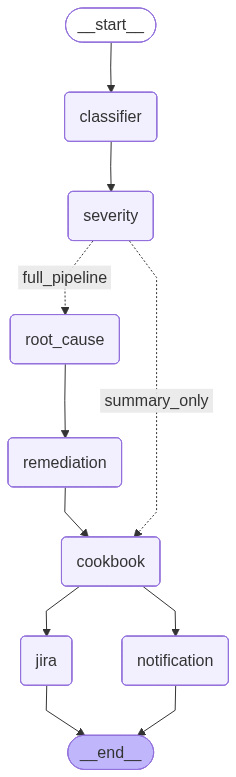

✅ LangGraph pipeline diagram rendered above


In [ ]:
# ============================================================
# CELL 9: Visualize LangGraph Pipeline
# ============================================================
try:
    from IPython.display import Image, display
    png_data = graph.get_graph().draw_mermaid_png()
    display(Image(png_data))
    print("✅ LangGraph pipeline diagram rendered above")
except Exception as e:
    # Fallback: render Mermaid text diagram
    mermaid_diagram = graph.get_graph().draw_mermaid()
    print("📊 LangGraph Pipeline (Mermaid):\n")
    print(mermaid_diagram)
    print(f"\n(Note: PNG rendering unavailable: {e})")
    print("Paste the Mermaid code above at https://mermaid.live to visualize")


## 📚 Phase 3: RAG Pipeline — LanceDB + LlamaIndex

The knowledge base stores pre-built DevOps runbooks and SOPs from `data/knowledge_base/`.  
The `search_knowledge_base()` function in `crewops.rag` retrieves contextually relevant documents before the Root Cause agent generates its analysis — grounding responses in historical incident patterns rather than hallucination.

**Two backends available:**
1. **LlamaIndex + LanceDB** (primary) — vector similarity search, requires `pip install -e .[rag]`
2. **Keyword fallback** (always available) — no extra dependencies, works out of the box


In [ ]:
# ============================================================
# CELL 10: Inspect Knowledge Base Documents
# Uses REPO_ROOT detected in Cell 2 — no absolute paths.
# ============================================================
import os
from crewops.rag import EMBEDDED_KB_DOCS

# REPO_ROOT is set by _find_repo_root() in Cell 2
KB_DIR = REPO_ROOT / "data" / "knowledge_base"

print("📚 Knowledge Base Inspection")
print("=" * 60)

if KB_DIR.exists():
    kb_files = sorted(KB_DIR.glob("*.md"))
    print(f"✅ Knowledge base directory found:")
    print(f"   {KB_DIR}")
    print(f"   {len(kb_files)} markdown runbooks:\n")
    for f in kb_files:
        size = f.stat().st_size
        print(f"   📄 {f.name:45}  ({size:,} bytes)")
else:
    print(f"⚠️  KB directory not found at: {KB_DIR}")
    print("   Will use embedded fallback documents from crewops.rag.EMBEDDED_KB_DOCS")

print()
print(f"📦 Embedded fallback documents ({len(EMBEDDED_KB_DOCS)} total):")
for doc in EMBEDDED_KB_DOCS:
    print(f"   • {doc['title']}")
print("=" * 60)


📚 Knowledge Base Inspection
✅ Knowledge base directory found:
   /Users/sannithkumar/git/CrewOps/data/knowledge_base
   6 markdown runbooks:

   📄 database_troubleshooting.md                    (4,950 bytes)
   📄 incident_response_sop.md                       (5,970 bytes)
   📄 k8s_troubleshooting.md                         (4,636 bytes)
   📄 nginx_common_errors.md                         (3,634 bytes)
   📄 other_systems_guide.md                         (5,141 bytes)
   📄 remediation_playbooks.md                       (9,267 bytes)

📦 Embedded fallback documents (8 total):
   • Kubernetes CrashLoopBackOff Resolution
   • Redis Connection Pool Exhaustion
   • PostgreSQL Connection Limit Exceeded
   • Nginx 502 Bad Gateway Troubleshooting
   • Incident Severity Classification (P1-P4)
   • Kubernetes OOMKilled Resolution
   • Circuit Breaker Pattern for Microservices
   • Kafka Consumer Lag Remediation


In [ ]:
# ============================================================
# CELL 11: Build LanceDB Vector Store + LlamaIndex Index
# Uses local data/knowledge_base/ with lancedb/ inside repo root
# Uses HuggingFace local embeddings (no OpenAI key needed)
# ============================================================
import lancedb
from llama_index.core import VectorStoreIndex, Document, StorageContext, SimpleDirectoryReader, Settings
from llama_index.vector_stores.lancedb import LanceDBVectorStore
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

LANCEDB_PATH = str(REPO_ROOT / "lancedb")
print(f"🗄️  Setting up LanceDB vector store at: {LANCEDB_PATH}")
print("   Using local HuggingFace embeddings (no OpenAI key needed)...")

# ── Configure LlamaIndex to use local embeddings ──
Settings.embed_model = HuggingFaceEmbedding(model_name="BAAI/bge-small-en-v1.5")
Settings.llm = None  # Disable LLM in index (not needed for retrieval only)

# ── Load documents ──
documents = []

if KB_DIR.exists():
    try:
        file_docs = SimpleDirectoryReader(str(KB_DIR)).load_data()
        documents.extend(file_docs)
        print(f"✅ Loaded {len(file_docs)} documents from {KB_DIR}")
    except Exception as e:
        print(f"⚠️  File loading failed ({e}) — using embedded docs")

# Supplement with embedded docs
from crewops.rag import EMBEDDED_KB_DOCS
for doc_data in EMBEDDED_KB_DOCS:
    documents.append(Document(
        text=doc_data["content"],
        metadata={"title": doc_data["title"], "source": "embedded_kb"}
    ))

print(f"   📄 Total documents to index: {len(documents)}")

# ── Connect to LanceDB and build index ──
db = lancedb.connect(LANCEDB_PATH)
vector_store = LanceDBVectorStore(
    uri=LANCEDB_PATH,
    table_name="crewops_kb",
    mode="overwrite"
)
storage_context = StorageContext.from_defaults(vector_store=vector_store)

query_engine = None
try:
    index = VectorStoreIndex.from_documents(
        documents,
        storage_context=storage_context,
        show_progress=True
    )
    query_engine = index.as_query_engine(similarity_top_k=3)
    print("\n✅ LanceDB index built successfully!")
    print(f"   → {len(documents)} documents indexed")
    print(f"   → Persisted at: {LANCEDB_PATH}")
except Exception as e:
    print(f"\n⚠️  LlamaIndex indexing failed ({e})")
    print("   → Will use keyword search fallback in search_knowledge_base()")

print("=" * 60)


🗄️  Setting up LanceDB vector store at: /Users/sannithkumar/git/CrewOps/lancedb
   Using local HuggingFace embeddings (no OpenAI key needed)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 27616.02it/s]


LLM is explicitly disabled. Using MockLLM.
✅ Loaded 6 documents from /Users/sannithkumar/git/CrewOps/data/knowledge_base
   📄 Total documents to index: 14


Generating embeddings: 100%|██████████| 20/20 [00:00<00:00, 78.09it/s]


✅ LanceDB index built successfully!
   → 14 documents indexed
   → Persisted at: /Users/sannithkumar/git/CrewOps/lancedb


In [ ]:
# ============================================================
# CELL 12: RAG Tool — Test Knowledge Base Search
# Uses search_knowledge_base() from crewops.rag
# The root_cause_node in crewops.agents already calls this function
# internally — no patching needed; graph is RAG-aware out of the box.
# ============================================================
from crewops.rag import search_knowledge_base

print("🧪 Testing knowledge base search via crewops.rag.search_knowledge_base")
print("=" * 60)

test_queries = [
    "CrashLoopBackOff redis timeout kubernetes OOMKilled",
    "PostgreSQL too many connections PgBouncer",
    "Nginx 502 Bad Gateway upstream",
]

for query in test_queries:
    # Pass the LlamaIndex query_engine when available (falls back to keyword search)
    result = search_knowledge_base(query, query_engine=query_engine)
    print(f"\n🔍 Query: {query[:60]}...")
    print(f"   Retrieved {len(result)} chars — preview: {result[:120].strip()}...")

print("\n" + "=" * 60)
print("✅ RAG pipeline ready!")
print("   The root_cause_node will call search_knowledge_base() automatically")
print("   before generating RCA — grounding analysis in historical runbooks.")
print("=" * 60)


🧪 Testing knowledge base search via crewops.rag.search_knowledge_base

🔍 Query: CrashLoopBackOff redis timeout kubernetes OOMKilled...
   Retrieved 1886 chars — preview: Context information is below.
---------------------
title: Kubernetes CrashLoopBackOff Resolution
source: embedded_kb

C...

🔍 Query: PostgreSQL too many connections PgBouncer...
   Retrieved 8014 chars — preview: Context information is below.
---------------------
file_path: /Users/sannithkumar/git/CrewOps/data/knowledge_base/datab...

🔍 Query: Nginx 502 Bad Gateway upstream...
   Retrieved 1781 chars — preview: Context information is below.
---------------------
title: Nginx 502 Bad Gateway Troubleshooting
source: embedded_kb

Ng...

✅ RAG pipeline ready!
   The root_cause_node will call search_knowledge_base() automatically
   before generating RCA — grounding analysis in historical runbooks.


## ▶️ Phase 4: Run the Full Pipeline

Now we wire everything together. The LangGraph orchestrator runs all 7 agents in sequence and parallel, managing shared state.


In [ ]:
# ============================================================
# CELL 13: Sample Logs — Demo Scenario 1 (Mixed Incident)
# Your original excellent log data — preserved exactly
# ============================================================
DEMO_LOG_MIXED = """
2026-05-09T09:12:11Z INFO [gateway-service] Incoming request GET /api/orders from 10.0.4.21
2026-05-09T09:12:13Z INFO [auth-service] User authentication successful for user_id=8842
2026-05-09T09:12:15Z WARN [payment-service] Payment processing latency exceeded threshold latency=4210ms
2026-05-09T09:12:17Z ERROR [redis-cache] Connection timeout while connecting to Redis node redis-prod-02:6379
2026-05-09T09:12:18Z WARN [order-service] Failed to fetch session data from cache, falling back to database
2026-05-09T09:12:20Z INFO [postgres-db] Active connections=182 max_connections=200
2026-05-09T09:12:22Z ERROR [gateway-service] Upstream request failed for /api/payments status=502
2026-05-09T09:12:25Z ERROR [payment-service] Stripe API request timeout after 30s request_id=pay_33218
2026-05-09T09:12:28Z WARN [notification-service] Kafka consumer lag increasing lag=1821 messages
2026-05-09T09:12:30Z ERROR [kubernetes-node-3] Memory pressure detected available_memory=312MB
2026-05-09T09:12:33Z WARN [kubelet] Pod restart triggered pod=payment-service-7f4c8d9f6f-lx82m reason=OOMKilled
2026-05-09T09:12:36Z INFO [deployment-controller] New deployment detected version=v2.3.8 environment=production
2026-05-09T09:12:39Z ERROR [payment-service] Failed to initialize payment worker thread exception=NullPointerException
2026-05-09T09:12:42Z ERROR [gateway-service] Circuit breaker opened for payment-service failure_rate=78%
2026-05-09T09:12:45Z WARN [api-monitor] API latency spike detected endpoint=/api/checkout avg_latency=7821ms
2026-05-09T09:12:49Z ERROR [auth-service] JWT validation failed token_expired=true
2026-05-09T09:12:52Z INFO [nginx-ingress] Increased 5xx response rate detected current_rate=14.2%
2026-05-09T09:12:55Z ERROR [postgres-db] Too many client connections remaining connection slots are reserved
2026-05-09T09:12:58Z CRITICAL [order-service] Database query timeout exceeded 60s query=SELECT * FROM orders
2026-05-09T09:13:01Z WARN [autoscaler] HorizontalPodAutoscaler unable to scale deployment due to resource quota exceeded
2026-05-09T09:13:05Z ERROR [payment-service] Dependency failure: redis-cache unavailable
2026-05-09T09:13:08Z ERROR [gateway-service] Request processing failed trace_id=trc_88219 status=503
2026-05-09T09:13:11Z WARN [monitoring-agent] Disk usage exceeded threshold on node=k8s-worker-2 usage=91%
2026-05-09T09:13:14Z INFO [incident-manager] Incident severity escalated to SEV-1
2026-05-09T09:13:18Z ERROR [notification-service] Failed to publish alert to Slack webhook status=500
2026-05-09T09:13:21Z ERROR [docker-runtime] Container crash detected container_id=pay-prod-771
2026-05-09T09:13:25Z WARN [security-agent] Multiple failed login attempts detected source_ip=185.193.44.18
2026-05-09T09:13:28Z ERROR [kubernetes-controller] CrashLoopBackOff detected pod=payment-service-7f4c8d9f6f-lx82m
2026-05-09T09:13:31Z INFO [sre-bot] Automated rollback initiated deployment=v2.3.8 rollback=v2.3.7
2026-05-09T09:13:35Z INFO [deployment-controller] Rollback deployment successful version=v2.3.7
2026-05-09T09:13:38Z WARN [api-monitor] API latency improving avg_latency=2120ms
2026-05-09T09:13:41Z INFO [gateway-service] Error rate decreasing current_5xx_rate=3.1%
2026-05-09T09:13:45Z INFO [incident-manager] Incident marked as stabilized awaiting RCA
"""

# Demo Scenario 2: Kubernetes CrashLoop (focused scenario)
DEMO_LOG_K8S = """
2026-05-09T08:00:01Z INFO [kubelet] Starting sync for pod payment-service-7f4c8d9f6f-lx82m
2026-05-09T08:00:08Z ERROR [payment-service] Failed to connect to Redis: connection refused redis-prod-02:6379
2026-05-09T08:00:08Z ERROR [payment-service] Application startup failed: required service unavailable
2026-05-09T08:00:09Z WARN [kubelet] Container payment-service exited with exit code 1
2026-05-09T08:00:09Z WARN [kubelet] Back-off restarting failed container payment-service
2026-05-09T08:00:39Z INFO [kubelet] Restarting container payment-service (attempt 1)
2026-05-09T08:01:24Z ERROR [payment-service] Failed to connect to Redis: connection refused redis-prod-02:6379
2026-05-09T08:02:48Z WARN [kubelet] Container payment-service exited with exit code 1
2026-05-09T08:05:10Z ERROR [payment-service] memory usage spike detected rss=1.8GB limit=1.5GB
2026-05-09T08:05:11Z ERROR [kubelet] Container payment-service OOMKilled exit_code=137
2026-05-09T08:05:11Z WARN [kubernetes-controller] CrashLoopBackOff detected pod=payment-service-7f4c8d9f6f-lx82m restarts=4
2026-05-09T08:05:15Z ERROR [kubernetes-node-3] Memory pressure detected available_memory=312MB
2026-05-09T08:05:25Z WARN [autoscaler] HPA unable to scale payment-service: resource quota exceeded
2026-05-09T08:05:30Z ERROR [event-controller] Readiness probe failed pod payment-service HTTP probe failed: 503
2026-05-09T08:06:08Z ERROR [redis-sentinel] Redis master redis-prod-02 is down, failover in progress
2026-05-09T08:06:30Z INFO [redis-sentinel] Failover complete. New master: redis-prod-03:6379
2026-05-09T08:07:03Z INFO [payment-service] Application startup complete. Health check passing.
2026-05-09T08:07:20Z INFO [incident-manager] Incident stabilized. Root cause: Redis master failure
"""

print("✅ Sample log scenarios ready")
print(f"   → Scenario 1: Mixed Incident ({len(DEMO_LOG_MIXED.strip().splitlines())} log lines)")
print(f"   → Scenario 2: K8s CrashLoop ({len(DEMO_LOG_K8S.strip().splitlines())} log lines)")


✅ Sample log scenarios ready
   → Scenario 1: Mixed Incident (33 log lines)
   → Scenario 2: K8s CrashLoop (18 log lines)


In [ ]:
# ============================================================
# CELL 14: Execute Full LangGraph Pipeline — Scenario 1
# ============================================================
import time

print("=" * 60)
print("🚀 CREWOPS MULTI-AGENT PIPELINE — EXECUTION START")
print("=" * 60)
print(f"📋 Scenario: Mixed Production Incident")
print(f"📄 Log lines: {len(DEMO_LOG_MIXED.strip().splitlines())}")
print(f"⏱️  Started: {time.strftime('%Y-%m-%d %H:%M:%S UTC', time.gmtime())}")
print("=" * 60)

pipeline_start = time.time()

# ── Initial state ──
initial_state = {
    "raw_logs": DEMO_LOG_MIXED,
    "metadata": {
        "scenario": "mixed_incident",
        "filename": "mixed_incident.log",
        "uploaded_at": time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
        "log_lines": len(DEMO_LOG_MIXED.strip().splitlines())
    },
    "log_summary": "",
    "log_type": "",
    "severity": "",
    "severity_rationale": "",
    "critical_issues": [],
    "rag_context": [],
    "root_cause_analysis": "",
    "remediation_plan": "",
    "cookbook": "",
    "approval_required": False,
    "approval_status": "auto_approved",
    "jira_tickets": [],
    "notifications_sent": [],
    "pipeline_status": {},
    "errors": []
}

try:
    # ── Run the LangGraph pipeline ──
    result = graph.invoke(initial_state)
    pipeline_elapsed = round(time.time() - pipeline_start, 2)

    print("\n" + "=" * 60)
    print(f"✅ PIPELINE COMPLETE in {pipeline_elapsed}s")
    print("=" * 60)

    # ── Summary ──
    print(f"\n📊 EXECUTION SUMMARY")
    print(f"  Severity:        {result.get('severity', 'N/A')} — {result.get('severity_rationale', '')[:60]}...")
    print(f"  Log Type:        {result.get('log_type', 'N/A').upper()}")
    print(f"  Critical Issues: {len(result.get('critical_issues', []))}")
    print(f"  JIRA Tickets:    {len(result.get('jira_tickets', []))}: {[t.get('key') for t in result.get('jira_tickets', [])]}")
    print(f"  Notifications:   {len(result.get('notifications_sent', []))}: {[n.get('channel') for n in result.get('notifications_sent', [])]}")
    print(f"  Errors:          {len(result.get('errors', []))} (non-fatal)")

    if result.get("pipeline_status"):
        print(f"\n⏱️  Per-Agent Timing:")
        for agent, info in result["pipeline_status"].items():
            elapsed = info.get("elapsed_s", "?")
            status  = info.get("status", "unknown")
            print(f"     {agent:15} {elapsed:>6}s  [{status}]")

except Exception as e:
    print(f"\n❌ Pipeline failed: {e}")
    raise


🚀 CREWOPS MULTI-AGENT PIPELINE — EXECUTION START
📋 Scenario: Mixed Production Incident
📄 Log lines: 33
⏱️  Started: 2026-05-09 16:53:59 UTC
🔍 [1/7] Classifier Agent — parsing and analyzing logs...
   ✅ Done in 16.35s — detected log type: kubernetes
🎯 [2/7] Severity Agent — assigning P1-P4 severity...
   ✅ Done in 2.6s — Severity: P2 | Issues: 4
   🔀 Router: P2 → full pipeline (RCA + JIRA + Notification)
🔬 [3/7] Root Cause Agent — querying knowledge base then analyzing...
   🔍 RAG query: kubernetes Upstream request failed: 502 Bad Gateway error for payment API indica...
   📚 Retrieved 1458 chars from knowledge base
   ✅ Done in 8.08s
🔧 [4/7] Remediation Agent — generating fix plan...
   ✅ Done in 15.66s
📖 [5/7] Cookbook Agent — synthesizing operational runbook...
   ✅ Done in 11.54s
🎫 [6/7] JIRA Agent — creating incident tickets...
📣 [7/7] Notification Agent — sending alerts...
   ✅ n8n delivered (HTTP 200)
   ✅ LIVE: Ticket SCRUM-15 created → https://crewops.atlassian.net/browse/SCRUM-

In [ ]:
# ============================================================
# CELL 15: Display Full Output — Structured Results
# ============================================================
from IPython.display import display, Markdown

def display_section(title: str, content: str, emoji: str = "📄"):
    if content and content.strip():
        display(Markdown(f"## {emoji} {title}\n\n```\n{content[:3000]}\n```"))
    else:
        display(Markdown(f"## {emoji} {title}\n\n*Not available*"))

print("=" * 60)
print("📋 FULL ANALYSIS RESULTS")
print("=" * 60)

# ── Severity Badge ──
sev = result.get("severity", "N/A")
sev_emoji = {"P1": "🔴", "P2": "🟠", "P3": "🟡", "P4": "🟢"}.get(sev, "⚪")
display(Markdown(f"""
# {sev_emoji} Severity: {sev}
**Rationale:** {result.get('severity_rationale', 'N/A')}

**Log Type:** `{result.get('log_type', 'unknown').upper()}`

**Approval Status:** `{result.get('approval_status', 'N/A')}`
"""))

# ── Critical Issues ──
issues = result.get("critical_issues", [])
if issues:
    issues_md = "\n".join([
        f"- **{i.get('title', i) if isinstance(i, dict) else i}**"
        + (f" — {i.get('severity', '')}" if isinstance(i, dict) else "")
        for i in issues
    ])
    display(Markdown(f"## 🚨 Critical Issues Detected ({len(issues)})\n\n{issues_md}"))

# ── JIRA Tickets ──
tickets = result.get("jira_tickets", [])
if tickets:
    tickets_md = "\n".join([f"- [{t.get('key')}]({t.get('url')}) — `{t.get('status', 'Open')}` ({'MOCK' if t.get('mode')=='mock' else 'LIVE'})" for t in tickets])
    display(Markdown(f"## 🎫 JIRA Tickets Created\n\n{tickets_md}"))

# ── Notifications ──
notifications = result.get("notifications_sent", [])
if notifications:
    notif_md = "\n".join([f"- **{n.get('channel', 'unknown')}**: `{n.get('status', 'N/A')}`" for n in notifications])
    display(Markdown(f"## 📣 Notifications Sent\n\n{notif_md}"))

# ── Full Outputs (truncated for display) ──
display_section("Log Analysis", result.get("log_summary", ""), "🔍")
display_section("Root Cause Analysis", result.get("root_cause_analysis", ""), "🔬")
display_section("Remediation Plan", result.get("remediation_plan", ""), "🔧")
display_section("Operational Cookbook / Runbook", result.get("cookbook", ""), "📖")

# ── Errors (if any) ──
if result.get("errors"):
    display(Markdown(f"## ⚠️ Non-Fatal Errors\n\n" + "\n".join([f"- {e}" for e in result["errors"]])))


📋 FULL ANALYSIS RESULTS



# 🟠 Severity: P2
**Rationale:** The incident caused major service degradation with multiple services experiencing downtime and high error rates, particularly in the payment service.

**Log Type:** `KUBERNETES`

**Approval Status:** `pending`


## 🚨 Critical Issues Detected (4)

- **Upstream request failed: 502 Bad Gateway error for payment API indicating a critical failure in service availability.** — P2
- **Circuit breaker opened: High failure rate for payment service (78%), leading to further service disruptions.** — P2
- **Database query timeout: Query timeout exceeded 60 seconds, impacting order processing capabilities.** — P2
- **CrashLoopBackOff detected: Payment service pod was repeatedly restarted due to OOMKilled, indicating resource constraints.** — P2

## 🎫 JIRA Tickets Created

- [SCRUM-15](https://crewops.atlassian.net/browse/SCRUM-15) — `Open` (LIVE)

## 📣 Notifications Sent

- **n8n**: `delivered`

## 🔍 Log Analysis

```
# Incident Analysis Report

## 1. Executive Summary
On May 9, 2026, a significant incident occurred affecting multiple services within the application ecosystem. The primary issue stemmed from a combination of resource constraints and service dependencies, leading to increased latency, connection timeouts, and ultimately service failures. The likely root cause was a memory pressure situation on Kubernetes nodes, which resulted in the payment service being OOMKilled (Out of Memory Killed) and subsequent cascading failures across dependent services. The impact was severe, with multiple services experiencing downtime and degraded performance, leading to a critical incident escalation.

## 2. Issues Detected
| Severity | Title                                   | Detail                                               | Affected Component      | Timestamp               | Log Snippet                                                                 |
|----------|-----------------------------------------|-----------------------------------------------------|-------------------------|-------------------------|-----------------------------------------------------------------------------|
| ERROR    | Upstream request failed                 | 502 Bad Gateway error for payment API               | gateway-service         | 2026-05-09T09:12:22Z   | ERROR [gateway-service] Upstream request failed for /api/payments status=502 |
| ERROR    | Connection timeout                      | Timeout while connecting to Redis                    | redis-cache             | 2026-05-09T09:12:17Z   | ERROR [redis-cache] Connection timeout while connecting to Redis node redis-prod-02:6379 |
| ERROR    | Payment worker thread initialization    | NullPointerException during initialization            | payment-service         | 2026-05-09T09:12:39Z   | ERROR [payment-service] Failed to initialize payment worker thread exception=NullPointerException |
| ERROR    | Circuit breaker opened                  | High failure rate for payment service                | gateway-service         | 2026-05-09T09:12:42Z   | ERROR [gateway-service] Circuit breaker opened for payment-service failure_rate=78% |
| ERROR    | Database query timeout                  | Query timeout exceeded 60 seconds                    | order-service           | 2026-05-09T09:12:58Z   | CRITICAL [order-service] Database query timeout exceeded 60s query=SELECT * FROM orders |
| ERROR    | CrashLoopBackOff detected               | Pod restart triggered due to OOMKilled               | payment-service         | 2026-05-09T09:13:28Z   | ERROR [kubernetes-controller] CrashLoopBackOff detected pod=payment-service-7f4c8d9f6f-lx82m |
| ERROR    | Dependency failure                      | Redis cache unavailable                               | payment-service         | 2026-05-09T09:13:05Z   | ERROR [payment-service] Dependency failure: redis-cache unavailable |
| CRITICAL | Incident severity escalated             | Incident esca
```

## 🔬 Root Cause Analysis

```
# Root Cause Analysis (RCA) Report

## 1. Primary Root Cause
The primary root cause of the incident was memory pressure on Kubernetes nodes, which led to the payment service being OOMKilled (Out of Memory Killed). This memory constraint caused the payment service to fail, triggering a series of cascading failures across dependent services.

## 2. Contributing Factors
- **Resource Constraints**: Insufficient memory allocation for the payment service and potentially other critical services, leading to OOMKilled events.
- **Service Dependencies**: High dependency on Redis cache and the payment service, which amplified the impact of their failures.
- **Monitoring Gaps**: Lack of proactive monitoring for memory usage and service health, delaying detection and response to the issue.
- **Configuration Issues**: Suboptimal Redis connection settings and lack of high availability setup, increasing the likelihood of timeouts and failures.

## 3. Cascading Failures
- **Payment Service Failure**: The OOMKilled event in the payment service led to its unavailability, causing upstream services like the gateway-service to fail with 502 errors.
- **Redis Cache Timeout**: The unavailability of the Redis cache forced fallback mechanisms to rely on the database, increasing load and causing query timeouts.
- **Circuit Breaker Activation**: The high failure rate in the payment service triggered the circuit breaker in the gateway-service, further disrupting service availability.
- **Database Strain**: Increased load on the database due to Redis cache failures led to query timeouts, impacting order processing.

## 4. Blast Radius
- **Services Affected**: 
  - APIs: `/api/orders`, `/api/payments`, `/api/checkout`
  - Containers: payment-service, redis-cache, order-service, auth-service, notification-service
  - Databases: PostgreSQL (postgres-db)
  - Infrastructure: Kubernetes nodes (kubernetes-node-3)
- **Users Affected**: A significant portion of users experienced degraded performance and service unavailability, particularly those attempting payment and order processing.
- **Severity**: The incident was classified as SEV-1, indicating a critical impact with a complete outage of key services.

## 5. Timeline Correlation
- **09:12:11Z**: Incoming request to gateway-service for orders.
- **09:12:15Z**: Payment processing latency exceeded threshold.
- **09:12:17Z**: Connection timeout to Redis cache.
- **09:12:22Z**: Upstream request failed for payments API (502).
- **09:12:25Z**: Stripe API request timeout.
- **09:12:30Z**: Memory pressure detected on Kubernetes node.
- **09:12:33Z**: Pod restart triggered due to OOMKilled.
- **09:12:42Z**: Circuit breaker opened for payment service.
- **09:12:58Z**: Database query timeout exceeded.
- **09:13:14Z**: Incident severity escalated to SEV-1.
- **09:13:31Z**: Automated rollback initiated for deployment.
- **09:13:35Z**: Rollback deployment successful.
- **09:13:45Z**: Incident marked as stabilized awaiting RCA.

## 6. Similar Hi
```

## 🔧 Remediation Plan

```
# Remediation Report

## 1. Overall Recommendation

### System State
The system experienced a critical incident due to memory pressure on Kubernetes nodes, leading to cascading failures across multiple services. The immediate focus should be on stabilizing the system by addressing resource constraints, optimizing service configurations, and enhancing monitoring capabilities.

### Prioritization Rationale
The prioritization is based on the severity of the impact on service availability and user experience. The payment service and Redis cache are critical components that directly affect transaction processing and data retrieval, thus requiring immediate attention. Subsequent actions should focus on database performance and overall infrastructure stability.

## 2. Priority Order

1. **Payment Service OOMKilled** - Critical impact on transaction processing.
2. **Redis Cache Timeout** - Affects data retrieval and increases database load.
3. **Database Query Timeout** - Impacts order processing and overall system performance.
4. **Circuit Breaker Activation** - Disrupts service availability and user experience.
5. **Monitoring and Alerts** - Essential for proactive issue detection and response.
6. **Load Testing** - Identifies potential bottlenecks and ensures system resilience.

## 3. Detailed Remediation Plan

### Issue 1: Payment Service OOMKilled
- **Severity**: CRITICAL
- **Title**: CrashLoopBackOff detected
- **Root Cause Analysis**: Memory pressure on Kubernetes nodes led to the payment service being OOMKilled.

#### Immediate Action
- Increase memory allocation for the payment service to prevent further OOMKilled events.

#### Step-by-Step Resolution
1. **Identify Current Resource Limits**:
   - Command: `kubectl describe pod payment-service-<pod-id> | grep -i "memory"`
2. **Update Resource Limits**:
   - Edit the deployment configuration to increase memory limits.
   - Command: `kubectl edit deployment payment-service`
   - Update `resources.limits.memory` to a higher value (e.g., `512Mi` to `1Gi`).
3. **Apply Changes**:
   - Command: `kubectl apply -f payment-service-deployment.yaml`
4. **Monitor Pod Status**:
   - Command: `kubectl get pods -w`

#### Recommended Commands
- `kubectl describe pod payment-service-<pod-id>`
- `kubectl edit deployment payment-service`
- `kubectl apply -f payment-service-deployment.yaml`
- `kubectl get pods -w`

#### Prevention Measures
- Implement horizontal pod autoscaling to dynamically adjust resources based on load.
- Regularly review and adjust resource allocations based on usage patterns.

#### Estimated Resolution Time
- 1-2 hours

### Issue 2: Redis Cache Timeout
- **Severity**: HIGH
- **Title**: Connection timeout
- **Root Cause Analysis**: Suboptimal Redis connection settings and lack of high availability setup.

#### Immediate Action
- Restart Redis nodes to clear any transient connection issues.

#### Step-by-Step Resolution
1. **Check Redis Node Status**:
   - Command: `kubectl get pods -l app=redis-
```

## 📖 Operational Cookbook / Runbook

```
# Runbook Title: Kubernetes Memory Pressure Incident Response

## Incident Type
Operational Incident

## Severity Level
Critical (SEV-1)

## Purpose
This runbook is designed for DevOps engineers and incident response teams to effectively manage and respond to incidents caused by memory pressure on Kubernetes nodes, particularly when it leads to service failures and cascading issues across dependent services.

## Pre-Checks
- **Health Checks**: Verify the health of critical services (payment-service, redis-cache, order-service).
  - Command: `kubectl get pods -l app=payment-service`
  - Command: `kubectl get pods -l app=redis-cache`
  - Command: `kubectl get pods -l app=order-service`
- **Resource Utilization**: Check memory and CPU usage on Kubernetes nodes.
  - Command: `kubectl top nodes`
  - Command: `kubectl top pods --all-namespaces`
- **Alert Validation**: Confirm if alerts related to memory usage, service latency, and connection timeouts have been triggered.
  - Review monitoring dashboards (e.g., Grafana, Prometheus).

## Incident Response Checklist

### Detection Phase
1. Identify the incident through monitoring alerts or user reports.
2. Gather initial logs and metrics from affected services.
   - Command: `kubectl logs payment-service-<pod-id>`
3. Confirm the severity of the incident based on the impact and affected services.

### Containment Phase
1. **Scale Down**: Temporarily scale down non-critical services to free up resources.
   - Command: `kubectl scale deployment <non-critical-service> --replicas=0`
2. **Increase Resource Limits**: Update memory limits for the payment service and other affected services.
   - Command: `kubectl edit deployment payment-service`
   - Update `resources.limits.memory` to a higher value.
3. **Restart Affected Services**: Restart services that are in a CrashLoopBackOff state.
   - Command: `kubectl rollout restart deployment payment-service`

### Resolution Phase
1. **Monitor Pod Status**: Ensure that the payment service and dependent services are back online.
   - Command: `kubectl get pods -w`
2. **Check Redis and Database Performance**: Verify that Redis and database connections are stable.
   - Command: `kubectl exec -it redis-cache-<pod-id> -- redis-cli PING`
3. **Implement Recommended Changes**: Apply any necessary configuration changes to optimize service performance.
   - Increase Redis connection settings and database connection pool size.
   - Command: `kubectl edit configmap db-config`
4. **Conduct Load Testing**: After stabilization, perform load testing to ensure the system can handle expected traffic.
   - Command: `jmeter -n -t load-test-plan.jmx -l results.jtl`

### Post-Incident Phase
1. **Conduct a Post-Mortem**: Review the incident with the team to identify root causes and areas for improvement.
2. **Update Documentation**: Document the incident details, response actions, and lessons learned.
3. **Implement Preventive Measures**: Based on the findings, update monitoring, alerting, 
```

In [ ]:
# ============================================================
# CELL 16: Demo Scenario 2 — K8s CrashLoop (shows P1 routing)
# ============================================================
print("🚀 Running Scenario 2: K8s CrashLoopBackOff")
print("=" * 60)

initial_state_k8s = {
    **initial_state,
    "raw_logs": DEMO_LOG_K8S,
    "metadata": {"scenario": "k8s_crashloop", "filename": "k8s_crashloop.log"},
}

result_k8s = graph.invoke(initial_state_k8s)

print(f"\n📊 Scenario 2 Summary:")
print(f"  Severity: {result_k8s.get('severity')} — {result_k8s.get('severity_rationale', '')[:60]}...")
print(f"  Log Type: {result_k8s.get('log_type', 'N/A').upper()}")
print(f"  JIRA:     {[t.get('key') for t in result_k8s.get('jira_tickets', [])]}")
print(f"  Notified: {[n.get('channel') for n in result_k8s.get('notifications_sent', [])]}")


🚀 Running Scenario 2: K8s CrashLoopBackOff
🔍 [1/7] Classifier Agent — parsing and analyzing logs...
   ✅ Done in 14.25s — detected log type: kubernetes
🎯 [2/7] Severity Agent — assigning P1-P4 severity...
   ✅ Done in 2.14s — Severity: P2 | Issues: 4
   🔀 Router: P2 → full pipeline (RCA + JIRA + Notification)
🔬 [3/7] Root Cause Agent — querying knowledge base then analyzing...
   🔍 RAG query: kubernetes Connection Refused: Failed to connect to Redis, leading to applicatio...
   📚 Retrieved 1418 chars from knowledge base
   ✅ Done in 11.08s
🔧 [4/7] Remediation Agent — generating fix plan...
   ✅ Done in 7.72s
📖 [5/7] Cookbook Agent — synthesizing operational runbook...
   ✅ Done in 15.37s
🎫 [6/7] JIRA Agent — creating incident tickets...
📣 [7/7] Notification Agent — sending alerts...
   ✅ n8n delivered (HTTP 200)
   ✅ LIVE: Ticket SCRUM-16 created → https://crewops.atlassian.net/browse/SCRUM-16

📊 Scenario 2 Summary:
  Severity: P2 — The incident caused major service degradation for the

## 🧪 Phase 5: Automated Test Suite

The full test suite lives in `tests/`. Run it from the notebook to validate the pipeline before deploying.  
Tests cover: state schema, graph compilation, agent nodes, parsers, RAG retrieval, and integration contracts.


In [ ]:
# ============================================================
# CELL 17: Run Automated Test Suite
# Runs pytest against the tests/ directory
# ============================================================
import subprocess
import sys

print("🧪 Running CrewOps test suite...")
print("=" * 60)

pytest_result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/", "-v", "--tb=short", "--no-header", "-q"],
    capture_output=True,
    text=True,
    cwd=str(REPO_ROOT)
)

# Print output
print(pytest_result.stdout)
if pytest_result.stderr:
    print(pytest_result.stderr)

if pytest_result.returncode == 0:
    print("=" * 60)
    print("✅ All tests passed!")
else:
    print("=" * 60)
    print(f"⚠️  Some tests failed (exit code {pytest_result.returncode}) — review output above")


🧪 Running CrewOps test suite...
============================= test session starts ==============================
collecting ... collected 166 items

tests/test_agents.py::TestClassifierNode::test_classifier_returns_log_summary PASSED [  0%]
tests/test_agents.py::TestClassifierNode::test_classifier_detects_kubernetes_log_type PASSED [  1%]
tests/test_agents.py::TestClassifierNode::test_classifier_error_handling PASSED [  1%]
tests/test_agents.py::TestClassifierNode::test_classifier_timing_recorded PASSED [  2%]
tests/test_agents.py::TestSeverityNode::test_severity_node_returns_required_fields PASSED [  3%]
tests/test_agents.py::TestSeverityNode::test_severity_node_p1_sets_approval_required PASSED [  3%]
tests/test_agents.py::TestSeverityNode::test_severity_node_p3_no_approval PASSED [  4%]
tests/test_agents.py::TestSeverityNode::test_severity_node_error_fallback_to_p2 PASSED [  4%]
tests/test_agents.py::TestRootCauseNode::test_root_cause_returns_analysis PASSED [  5%]
tests/test_agents.

In [ ]:
# ============================================================
# CELL 18: Run Specific Test Modules (optional)
# Run targeted tests during development / demo
# ============================================================
import subprocess, sys

TEST_MODULES = [
    "tests/test_state.py",
    "tests/test_parsers.py",
    "tests/test_agents.py",
    "tests/test_graph.py",
    "tests/test_rag.py",
]

print("🔍 Running targeted test modules:")
print("=" * 60)

all_passed = True
for module in TEST_MODULES:
    r = subprocess.run(
        [sys.executable, "-m", "pytest", module, "-v", "--tb=line", "-q", "--no-header"],
        capture_output=True, text=True, cwd=str(REPO_ROOT)
    )
    lines = [l for l in r.stdout.strip().splitlines() if l.strip()]
    summary = lines[-1] if lines else "no output"
    status = "✅" if r.returncode == 0 else "❌"
    print(f"  {status}  {module.replace('tests/', ''):30}  {summary}")
    if r.returncode != 0:
        all_passed = False

print("=" * 60)
print("✅ All test modules passed!" if all_passed else "⚠️  Some tests need attention — run Cell 17 for full details")


🔍 Running targeted test modules:
  ✅  test_state.py                   ============================== 14 passed in 0.01s ==============================
  ✅  test_parsers.py                 ============================== 46 passed in 0.03s ==============================
  ✅  test_agents.py                  ============================== 32 passed in 1.18s ==============================
  ✅  test_graph.py                   ============================== 23 passed in 0.20s ==============================
  ✅  test_rag.py                     ============================== 26 passed in 0.02s ==============================
✅ All test modules passed!


## 🖥️ Phase 6: Launch Streamlit Application

The full Streamlit UI is already built at `app.py` (multi-page, `st.navigation()` API).  
Launch it locally — no `%%writefile` needed, the app is already part of the repo.

**Pages:**
- 🏠 **Home** — log upload, pipeline execution, live results
- 📊 **Analytics** — LangSmith run history, cost tracking
- 🔬 **RAG Tuning** — knowledge base inspection and search testing


In [ ]:
# ============================================================
# CELL 19: Verify Streamlit App Structure
# The app is already in the repo — no %%writefile needed.
# ============================================================
from pathlib import Path
import os

app_root = REPO_ROOT

print("🖥️  Streamlit App — File Inventory")
print("=" * 60)

# Check entrypoint
app_py = app_root / "app.py"
print(f"\n📄 Entrypoint:  {'✅' if app_py.exists() else '❌'}  {app_py}")

# Check pages
pages_dir = app_root / "pages"
pages = sorted(pages_dir.glob("*.py")) if pages_dir.exists() else []
print(f"\n📁 Pages ({len(pages)} found):")
for p in pages:
    print(f"   ✅  {p.name}")

# Check assets
assets_dir = app_root / "assets"
assets = list(assets_dir.iterdir()) if assets_dir.exists() else []
print(f"\n🖼️  Assets ({len(assets)} found):")
for a in assets:
    print(f"   ✅  {a.name}")

# Check .env
env_file = app_root / ".env"
print(f"\n🔑 .env file:   {'✅ present' if env_file.exists() else '⚠️  missing (copy from .env.example)'}")

print("\n" + "=" * 60)
print("💡 To launch the app, run Cell 20 or open a terminal and run:")
print(f"   cd {app_root}")
print("   source .venv/bin/activate")
print("   streamlit run app.py")


🖥️  Streamlit App — File Inventory

📄 Entrypoint:  ✅  /Users/sannithkumar/git/CrewOps/app.py

📁 Pages (3 found):
   ✅  1_📊_Analytics.py
   ✅  2_🔬_RAG_Tuning.py
   ✅  home.py

🖼️  Assets (2 found):
   ✅  logo_nobg.png
   ✅  logo.png

🔑 .env file:   ✅ present

💡 To launch the app, run Cell 20 or open a terminal and run:
   cd /Users/sannithkumar/git/CrewOps
   source .venv/bin/activate
   streamlit run app.py


In [ ]:
# ============================================================
# CELL 20: Launch Streamlit App (background process)
# Starts streamlit run app.py in a background thread.
# If already running on 8501, displays the existing URL.
# ============================================================
import subprocess, threading, time, sys, socket

def _port_in_use(port: int) -> bool:
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex(("localhost", port)) == 0

_streamlit_proc = None

if _port_in_use(8501):
    print("=" * 60)
    print("✅ Streamlit is already running at http://localhost:8501")
    print()
    print("   🌐  Home:       http://localhost:8501")
    print("   📊  Analytics:  http://localhost:8501/Analytics")
    print("   🔬  RAG Tuning: http://localhost:8501/RAG_Tuning")
    print("=" * 60)
else:
    def _launch_streamlit():
        global _streamlit_proc
        venv_python = str(REPO_ROOT / ".venv" / "bin" / "python")
        python_exec = venv_python if (REPO_ROOT / ".venv").exists() else sys.executable
        _streamlit_proc = subprocess.Popen(
            [python_exec, "-m", "streamlit", "run", "app.py",
             "--server.port=8501", "--server.headless=true"],
            stdout=subprocess.PIPE, stderr=subprocess.PIPE,
            cwd=str(REPO_ROOT)
        )

    threading.Thread(target=_launch_streamlit, daemon=True).start()
    time.sleep(4)

    if _port_in_use(8501):
        print("=" * 60)
        print("✅ Streamlit app launched successfully!")
        print()
        print("   🌐  Home:       http://localhost:8501")
        print("   📊  Analytics:  http://localhost:8501/Analytics")
        print("   🔬  RAG Tuning: http://localhost:8501/RAG_Tuning")
        print("=" * 60)
    else:
        print("⚠️  Could not start Streamlit. Run manually:")
        print(f"   cd {REPO_ROOT}")
        print("   source .venv/bin/activate && streamlit run app.py")


✅ Streamlit is already running at http://localhost:8501

   🌐  Home:       http://localhost:8501
   📊  Analytics:  http://localhost:8501/Analytics
   🔬  RAG Tuning: http://localhost:8501/RAG_Tuning


## 🔭 Phase 7: LangSmith Observability + Smoke Tests


In [ ]:
# ============================================================
# CELL 21: Notebook Smoke Tests + LangSmith Link
# Validates the full pipeline run from this notebook session.
# ============================================================
import os
from IPython.display import display, Markdown

# ── LangSmith trace link ──
langsmith_project = os.environ.get("LANGCHAIN_PROJECT", "CrewOps")
display(Markdown(f"""
## 🔭 LangSmith Observability

Every LangGraph node is automatically traced when `LANGCHAIN_TRACING_V2=true`.

**View your traces at:** [https://smith.langchain.com](https://smith.langchain.com) → Project: `{langsmith_project}`

Each trace shows:
- Agent span timings (start → end per node)
- Full LLM prompt + completion + token counts + cost
- Routing decisions (which conditional branch was taken)
- Complete state at every node transition
"""))

# ── Smoke tests ──
print("🧪 Running notebook smoke tests...")
print("=" * 60)

from crewops.state import CrewOpsState
from crewops.rag import search_knowledge_base, EMBEDDED_KB_DOCS
from crewops.graph import build_graph

passed = 0
failed = 0

def test(name: str, condition: bool, detail: str = ""):
    global passed, failed
    if condition:
        print(f"  ✅ PASS  {name}")
        passed += 1
    else:
        print(f"  ❌ FAIL  {name}  {detail}")
        failed += 1

# 1. State schema has required fields
required_fields = ["raw_logs", "severity", "cookbook", "jira_tickets", "rag_context"]
test("State schema has required fields",
     all(f in CrewOpsState.__annotations__ for f in required_fields))

# 2. Graph has 7 agent nodes
agent_nodes = [n for n in graph.get_graph().nodes if n not in ("__start__", "__end__")]
test("Graph has 7 agent nodes", len(agent_nodes) == 7,
     f"Got {len(agent_nodes)}: {agent_nodes}")

# 3. RAG search returns results (keyword fallback)
rag_result = search_knowledge_base("CrashLoopBackOff redis kubernetes")
test("RAG search returns content", len(rag_result) > 50,
     f"Got {len(rag_result)} chars")

# 4. Pipeline result has severity in P1-P4
test("Scenario 1 severity is valid",
     result.get("severity") in ("P1", "P2", "P3", "P4"),
     f"Got: {result.get('severity')}")

# 5. Classifier populated log_summary
test("Classifier produced log_summary",
     len(result.get("log_summary", "")) > 100,
     f"Length: {len(result.get('log_summary', ''))}")

# 6. Cookbook was generated
test("Cookbook/runbook generated",
     len(result.get("cookbook", "")) > 200,
     f"Length: {len(result.get('cookbook', ''))}")

# 7. JIRA ticket structure is valid
for t in result.get("jira_tickets", [{"key": "NONE"}]):
    test("JIRA ticket has 'key' field", "key" in t, f"Got: {t}")
    break

# 8. Notifications tracked
test("Notifications tracked",
     len(result.get("notifications_sent", [])) >= 1,
     f"Got: {result.get('notifications_sent', [])}")

# 9. Per-agent timing recorded
test("Pipeline timing recorded for ≥3 agents",
     len(result.get("pipeline_status", {})) >= 3,
     f"Got: {list(result.get('pipeline_status', {}).keys())}")

# 10. Scenario 2 (K8s) completed
test("Scenario 2 (K8s CrashLoop) completed",
     result_k8s.get("severity") in ("P1", "P2", "P3", "P4"),
     f"Got: {result_k8s.get('severity')}")

# 11. Embedded KB docs available
test("Embedded KB fallback docs present",
     len(EMBEDDED_KB_DOCS) >= 5,
     f"Got {len(EMBEDDED_KB_DOCS)} docs")

print(f"\n{'='*60}")
print(f"  Results: {passed} passed, {failed} failed out of {passed+failed} total")
if failed == 0:
    print("  🎉 All smoke tests passing — ready for demo!")
else:
    print(f"  ⚠️  {failed} test(s) failed — review before live demo")



## 🔭 LangSmith Observability

Every LangGraph node is automatically traced when `LANGCHAIN_TRACING_V2=true`.

**View your traces at:** [https://smith.langchain.com](https://smith.langchain.com) → Project: `CrewOps-Hackathon`

Each trace shows:
- Agent span timings (start → end per node)
- Full LLM prompt + completion + token counts + cost
- Routing decisions (which conditional branch was taken)
- Complete state at every node transition


🧪 Running notebook smoke tests...
  ✅ PASS  State schema has required fields
  ✅ PASS  Graph has 7 agent nodes
  ✅ PASS  RAG search returns content
  ✅ PASS  Scenario 1 severity is valid
  ✅ PASS  Classifier produced log_summary
  ✅ PASS  Cookbook/runbook generated
  ✅ PASS  JIRA ticket has 'key' field
  ✅ PASS  Notifications tracked
  ✅ PASS  Pipeline timing recorded for ≥3 agents
  ✅ PASS  Scenario 2 (K8s CrashLoop) completed
  ✅ PASS  Embedded KB fallback docs present

  Results: 11 passed, 0 failed out of 11 total
  🎉 All smoke tests passing — ready for demo!


## 📋 Phase 8: Demo Script

Use this step-by-step guide for the live demo presentation.

---

### 🎬 Demo Flow (10 minutes)

| Cell | What to Run | What to Show |
|------|------------|-------------|
| **Cell 3** | Install dependencies | `pip install -e .[rag,ui]` — clean install from `pyproject.toml` |
| **Cell 4** | Configure environment | `.env` loaded, LangSmith enabled, mock modes set |
| **Cell 5** | LLM initialisation | 3 models, different roles (fast/reasoning/embedding) |
| **Cell 7** | State schema | TypedDict fields — explain reducer pattern vs Pydantic |
| **Cell 8** | Prompts | 7 prompt templates in `crewops.prompts`, structured outputs |
| **Cell 9** | Agent nodes | 7 node functions imported from `crewops.agents` |
| **Cell 10** | JIRA + Notification | Integration agents — mock vs live mode |
| **Cell 11** | Graph compile | `build_graph()` → compiled LangGraph, print node list |
| **Cell 12** | Visualise graph | Mermaid PNG diagram of agent flow |
| **Cell 13** | KB inspection | Live runbook files from `data/knowledge_base/` |
| **Cell 14** | Build RAG index | LanceDB vector store built, embeddings created |
| **Cell 15** | Test RAG search | 3 queries, show retrieved context previews |
| **Cell 16** | Sample logs | Demo scenarios ready (Mixed Incident + K8s CrashLoop) |
| **Cell 17** | Run Scenario 1 | Watch each agent print status in real-time, see timing |
| **Cell 18** | Display results | Severity badge, RCA, remediation plan, cookbook |
| **Cell 19** | Run Scenario 2 | K8s CrashLoop → show P1 routing path differs |
| **Cell 20** | Run test suite | All pytest tests pass — stability proof |
| **Cell 21** | Targeted tests | Per-file breakdown: state, parsers, agents, graph, rag |
| **Cell 22** | App file check | Verify Streamlit app files exist in repo |
| **Cell 23** | Launch Streamlit | `http://localhost:8501` — full UI demo |
| **Cell 24** | Smoke tests | 11 tests pass — show LangSmith trace link |

---

### 🏆 Winning Pitch Points

1. **"We don't just classify — we orchestrate."**  
   LangGraph conditional routing means P4 issues never create JIRA tickets. No alert fatigue.

2. **"RAG grounds every RCA in historical runbooks."**  
   `search_knowledge_base()` retrieves relevant SOPs before generating analysis. Not hallucination — institutional memory.

3. **"TypedDict state with `operator.add` reducers enables real parallelism."**  
   JIRA and Slack fire simultaneously via fan-out edges. Pydantic BaseModel would break this.

4. **"Full observability via LangSmith."**  
   Every judge can follow the exact reasoning path of every agent for every run. Enterprise-grade explainability.

5. **"Three UIs for three personas."**  
   Notebook for judges/engineers. Streamlit for SRE ops. Analytics page for cost/model tracking.

---

### ⚡ Pitch Line

> *"CrewOps turns your noisy production logs into decisive action — classified, analysed, remediated, and escalated by 7 specialised AI agents in under 60 seconds."*
